In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import csv
import pandas as pd
import os

from calibration import load_data, separate_ch_sig, rectify, bandpass_filter, lowpass_filter

In [24]:
# file_dir = r"C:\Users\User\Desktop\Maryam_Test_Files\MTS_Test\2026 - 01 - 14\Calibration" #path to the calibration file
file_dir = r"C:\Users\User\Desktop\Maryam_Test_Files\MTS_Test\2026 - 01 - 14" #path to the calibration file
date_timestamp = "2026-01-14_14-43-38"
file_name = r"\MTS_Test_FiltEMGData_2026-01-14_14-59-28" + ".csv" #name of the EMG file
df_filt = pd.read_csv(file_dir+file_name)
file_name = r"\MTS_Test_RawFormattedEMGData_2026-01-14_14-59-28" + ".csv" #name of the EMG file
df_raw = pd.read_csv(file_dir+file_name)
extension = ".csv"

# file_path = file_dir + file_name + extension

In [ ]:
file_name = r"\mtsLog_2026-01-14_14-59-28" + ".csv"
df_neuro = pd.read_csv(file_dir + file_name)
# 

In [27]:
filt_data = bandpass_filter(df_raw.EMG1)
rectified = []

rectified_real = []
for i in np.arange(len(filt_data)):
    rectified.append(np.abs(filt_data[i]))


for i in np.arange(len(df_filt["filt signal"])):
    rectified_real.append(np.abs(df_filt["filt signal"][i]))


band_b: 0.23130797944426512f, 0.0f, -0.46261595888853024f, 0.0f, 0.23130797944426512f
band_a: 1.0f, -2.1400945982631905f, 1.5528893358210751f, -0.5922328575740207f, 0.18337778320123216f
band_gainVal: 0.23130797944426512f


0.0007952855 0.001743131 0.001638923


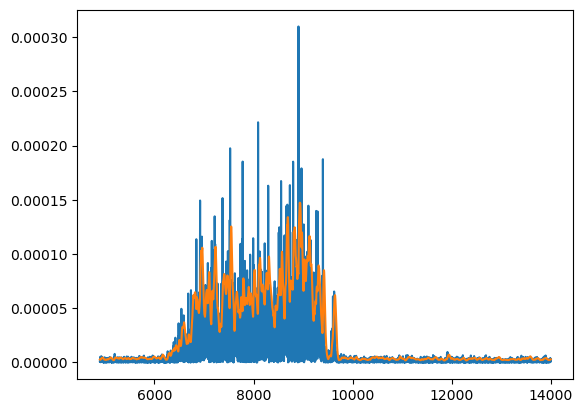

In [28]:
plt.plot(np.arange(4900,14000),rectified_real[4900:14000])
# plt.plot(rectified)
plt.plot(df_filt["env signal"][4900:14000])
print(np.max(df_filt["env signal"]),np.max(df_filt["filt signal"]),np.max(df_raw.EMG1))


In [ ]:
# adding this step for threshold selection -> requires the gain to not be modified in the online filter implementations
env_data = lowpass_filter(rectified)

In [15]:
max_sig = []
for ch in np.arange(16):
    if ch == 0:
        max_sig.append(np.max(df_filt["env signal"]))
    else:
        max_sig.append(0)

In [ ]:
print(max_sig)
plt.plot(df.EMG1)
plt.plot(rectified)
plt.plot(env_data)

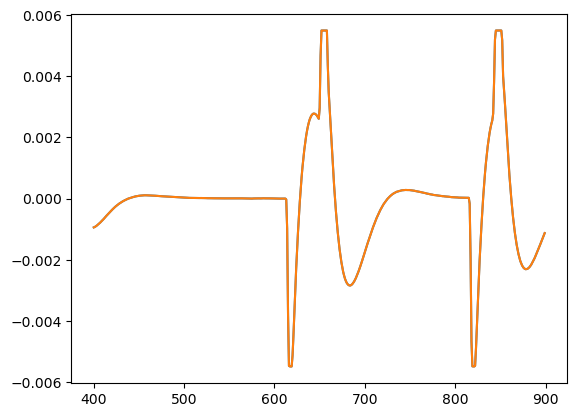

In [29]:
plt.plot(df_filt["TTL signal"][400:900])
plt.plot(df_raw.EMG2[400:900])

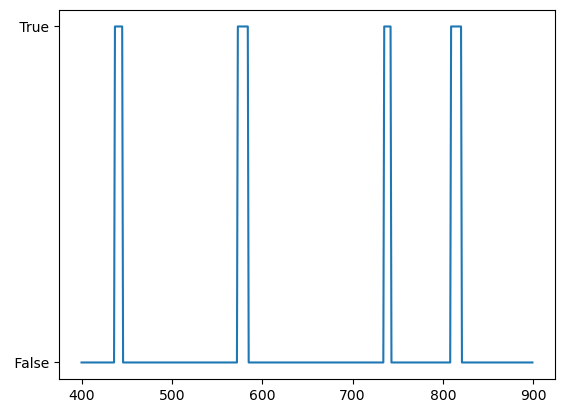

In [31]:
plt.plot(df_neuro["InputTrigger"][400:900])

In [18]:
save_file_name = "MVC_"+date_timestamp

with open(os.path.join(file_dir,save_file_name) + extension, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(max_sig)

old code for when EMG was logged as .txt

In [ ]:
directory = r"C:\Users\MRPICS\OneDrive - UW\MRPICS\maximalContraction"
file_name = r"\RawFormattedEMGData_2025 - 04 - 16_15 - 19 - 34" + ".txt"

full_stream = load_data(directory+file_name)


In [ ]:
full_stream = full_stream[:-1*int(full_stream[-1][0].split(" ")[1])]

In [ ]:
labels = full_stream[0]
emgData = separate_ch_sig(full_stream[1:])

In [ ]:

# minMaxSig=[["Min", "Max"]] 
# filtEMG = []
# for ch in np.arange(16):
#     if ch == 0:
#         buffer = rectify(bandpass_filter((emgData[ch, :, 1])))
#         filtEMG.append(buffer)
#         minMax = [np.min(buffer), np.max(buffer)]
#         minMaxSig = np.concatenate((minMaxSig, [minMax]), axis=0)
#     else:
#         buffer = rectify(bandpass_filter((emgData[ch, :, 1])))
#         filtEMG = np.concatenate((filtEMG, [buffer]), axis = 0)
#         minMax = [np.min(buffer), np.max(buffer)]
#         minMaxSig = np.concatenate((minMaxSig, [minMax]), axis=0)

minMaxSig=[] 
filtEMG = []
for ch in np.arange(16):
    if ch == 0:
        buffer = rectify(lowpass_filter((emgData[ch, :, 1])))
        filtEMG.append(buffer)
        minMax = [np.min(buffer), np.max(buffer)]
        minMaxSig.append(minMax)
    else:
        buffer = rectify(lowpass_filter((emgData[ch, :, 1])))
        filtEMG = np.concatenate((filtEMG, [buffer]), axis = 0)
        minMax = [np.min(buffer), np.max(buffer)]
        minMaxSig = np.concatenate((minMaxSig, [minMax]), axis=0)
        
print("test")

In [ ]:
file_name_save = r"\MinMax_2025 - 04 - 16_15 - 19 - 34" + ".csv"

with open(directory+file_name_save, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(minMaxSig)

In [ ]:
dir = r"C:\Users\User\Desktop\Maryam_Test_Files\MTS_Test\2026 - 01 - 14"
filename_filt = r"\MTS_Test_FiltEMGData_2026-01-14_14-26-49.csv"
filename_raw = r"\MTS_Test_RawFormattedEMGData_2026-01-13_14-49-50.csv"

In [ ]:
raw = pd.read_csv(dir+filename_raw)
r_filt = pd.read_csv(dir+filename_filt)

In [ ]:
low = 0
high = 10000
plt.plot(np.arange(low,high),raw.EMG1[low:high])
plt.plot(np.arange(low,high),r_filt["raw timestamp"][low:high])